# Ajax Match XML Explorer
**Data:** `data/XML_anonymized.xml` — video-analysis tagged instances from an Ajax match

Each **instance** = a tagged clip with:
- `start` / `end` → timestamp in seconds
- `code` → what was tagged (player, action, phase)
- `labels` → grouped metadata (SPELERS = players, HOOFDMOMENTEN = main moments, FASE = phase, SPELHERVATTING = restarts)

In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from collections import Counter, defaultdict
import html
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#21262d',
    'grid.linewidth': 0.5,
    'figure.titlesize': 16,
    'axes.titlesize': 13,
    'axes.titlepad': 12,
    'font.family': 'monospace',
})

AJAX_RED  = '#D2001A'
AJAX_WHITE = '#FFFFFF'
ACCENT    = '#58a6ff'
GOLD      = '#e3b341'
GREEN     = '#3fb950'
PURPLE    = '#bc8cff'
ORANGE    = '#f78166'

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ─── Parse XML ────────────────────────────────────────────────────────────────
XML_PATH = 'data/XML_anonymized.xml'

tree = ET.parse(XML_PATH)
root = tree.getroot()

# Also parse ROWS: code → RGB color mappings from the video analysis software
code_colors_raw = {}
rows_el = root.find('ROWS')
if rows_el is not None:
    for row in rows_el.findall('row'):
        code = row.findtext('code', '')
        r = int(row.findtext('R', 0))
        g = int(row.findtext('G', 0))
        b = int(row.findtext('B', 0))
        if code:
            code_colors_raw[html.unescape(code)] = (r/255, g/255, b/255)

# Parse all instances (inside ALL_INSTANCES)
records = []
for inst in root.findall('.//instance'):
    rec = {
        'id':        int(inst.findtext('ID', 0)),
        'start':     float(inst.findtext('start', 0)),
        'end':       float(inst.findtext('end',   0)),
        'code':      html.unescape(inst.findtext('code', '') or ''),
        'free_text': inst.findtext('free_text', '') or '',
    }
    rec['duration'] = rec['end'] - rec['start']

    groups = defaultdict(list)
    for lbl in inst.findall('label'):
        g = lbl.findtext('group', '')
        t = html.unescape(lbl.findtext('text', '') or '')
        if g and t:
            groups[g].append(t)

    rec['spelers']        = groups.get('SPELERS', [])        # Players involved
    rec['hoofdmomenten']  = groups.get('HOOFDMOMENTEN', [])  # Main moments (V>A, A>V, ...)
    rec['fase']           = groups.get('FASE', [])           # Phase (DEF 1/2/3, ATT 1/2/3)
    rec['spelhervatting'] = groups.get('SPELHERVATTING', []) # Set pieces / restarts

    records.append(rec)

df = pd.DataFrame(records)
df['start_min'] = df['start'] / 60
df['end_min']   = df['end']   / 60
df['n_players'] = df['spelers'].apply(len)

print(f'Parsed {len(df):,} instances  |  {len(code_colors_raw)} code-color mappings from ROWS')
print(f'Time span: {df["start"].min():.1f}s → {df["end"].max():.1f}s  ({df["end"].max()/60:.1f} min)')

Parsed 1,381 instances  |  50 code-color mappings from ROWS
Time span: 1509.6s → 8502.4s  (141.7 min)


In [3]:
# ─── Summary Statistics ────────────────────────────────────────────────────────
all_players  = sorted({p for ps in df['spelers'] for p in ps})
all_phases   = sorted({f for fs in df['fase'] for f in fs})
all_moments  = sorted({m for ms in df['hoofdmomenten'] for m in ms})
all_restarts = sorted({r for rs in df['spelhervatting'] for r in rs})
all_codes    = df['code'].value_counts()

print('=' * 60)
print(' AJAX MATCH XML — DATA OVERVIEW')
print('=' * 60)
print(f'  Total instances       : {len(df):,}')
print(f'  Time range            : {df["start_min"].min():.1f} – {df["end_min"].max():.1f} min')
print(f'  Avg clip duration     : {df["duration"].mean():.1f}s  (median: {df["duration"].median():.1f}s)')
print(f'  Unique codes          : {df["code"].nunique()}')
print(f'  Unique players tagged : {len(all_players)}')
print(f'  Phases                : {all_phases}')
print(f'  Main moments          : {all_moments}')
print(f'  Set pieces/restarts   : {len(all_restarts)} types')
print('=' * 60)

print('\nTop 15 codes (most used):')
print(all_codes.head(15).to_string())

print('\nDuration stats (seconds):')
print(df['duration'].describe().round(2).to_string())

 AJAX MATCH XML — DATA OVERVIEW
  Total instances       : 1,381
  Time range            : 25.2 – 141.7 min
  Avg clip duration     : 23.3s  (median: 21.2s)
  Unique codes          : 50
  Unique players tagged : 16
  Phases                : ['ATT 1', 'ATT 2', 'ATT 3', 'DEF 1', 'DEF 2', 'DEF 3']
  Main moments          : ['A>V', 'AANVALLEN', 'V>A', 'VERDEDIGEN']
  Set pieces/restarts   : 10 types

Top 15 codes (most used):
code
Player_12     95
Player_8      88
Player_7      82
Player_4      79
Player_5      73
BOP           72
Player_16     70
AANVALLEN     68
Player_11     65
V>A           62
VERDEDIGEN    57
Player_13     57
Player_3      55
A>V           54
Player_2      46

Duration stats (seconds):
count    1381.00
mean       23.28
std        10.76
min         0.20
25%        20.00
50%        21.18
75%        26.30
max       150.00


In [4]:
# ─── Full DataFrame preview ────────────────────────────────────────────────────
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_rows', 20)

display_df = df[['id','start_min','end_min','duration','code','spelers','hoofdmomenten','fase']].copy()
display_df.columns = ['ID','Start (min)','End (min)','Dur (s)','Code','Players','Moment','Phase']
display_df['Start (min)'] = display_df['Start (min)'].round(2)
display_df['End (min)']   = display_df['End (min)'].round(2)
display_df['Dur (s)']     = display_df['Dur (s)'].round(1)

print(f'Showing first 20 of {len(display_df)} instances:')
display(display_df.head(20))

Showing first 20 of 1381 instances:


,ID,Start (min),End (min),Dur (s),Code,Players,Moment,Phase
0,1,25.16,25.17,0.3,URBY,[],[],[]
1,2,29.60,30.08,29.0,Player_4,"[Player_4, Player_12]","[V>A, VERDEDIGEN]",[DEF 2]
2,3,29.60,29.88,16.6,DEF 2,"[Player_4, Player_12]",[],[DEF 2]
3,4,29.63,29.96,20.0,Player_12,[Player_12],[V>A],[]
4,5,29.64,29.88,14.5,VERDEDIGEN,"[Player_4, Player_12]",[VERDEDIGEN],[DEF 2]
5,6,29.65,29.67,1.0,START,[],[],[]
6,7,29.76,30.00,14.0,V>A,[],[V>A],[]
7,8,29.92,30.28,21.6,DEF 2,"[Player_2, Player_5, Player_9]",[],[DEF 2]
8,9,29.95,30.33,22.9,Player_2,"[Player_2, Player_5, Player_9, Player_8, Playe...",[V>A],[]
9,10,29.95,30.47,31.5,Player_5,"[Player_5, Player_9, Player_8, Player_13]","[V>A, A>V]",[]


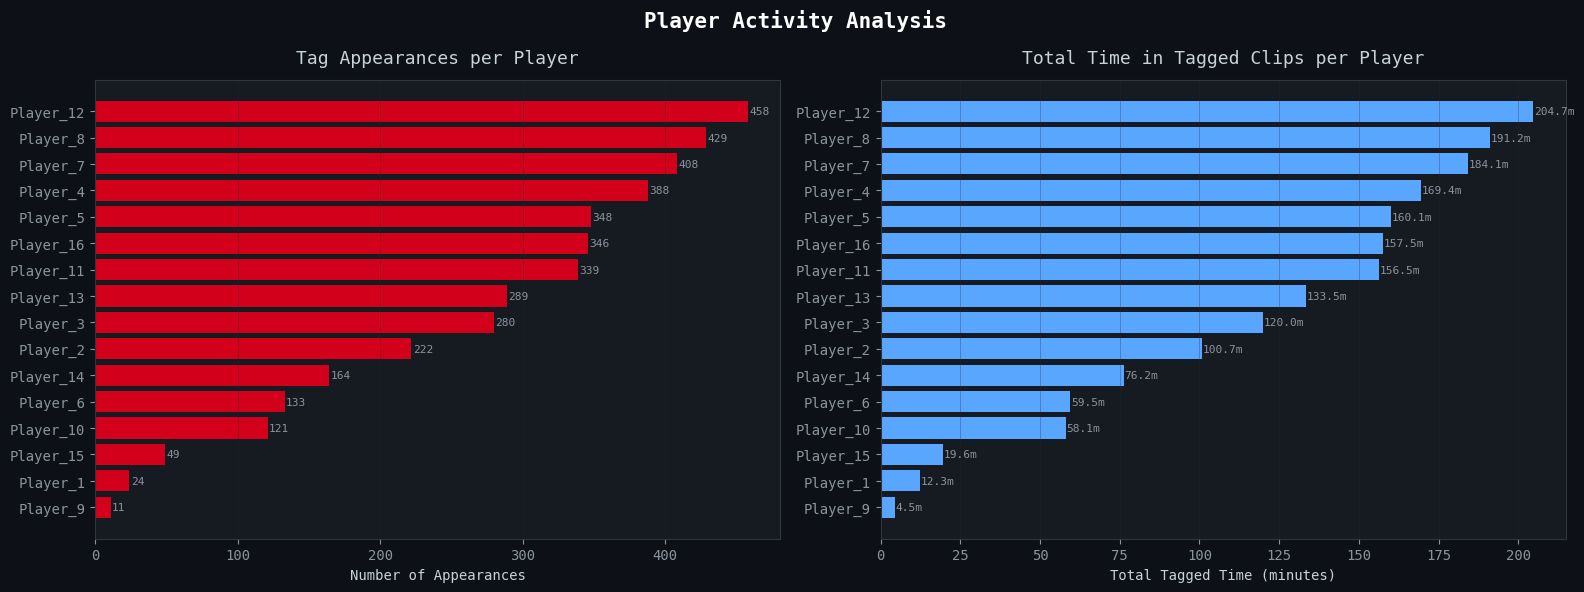


Player Stats Table:
   player  appearances  total_time_min  avg_duration_s  first_seen_min  last_seen_min
Player_12          458          204.66           26.81           29.60         141.13
 Player_8          429          191.22           26.74           29.95         141.03
 Player_7          408          184.12           27.08           30.35         140.55
 Player_4          388          169.37           26.19           29.60         140.28
 Player_5          348          160.12           27.61           29.92         127.54
Player_16          346          157.54           27.32           31.09         140.70
Player_11          339          156.45           27.69           37.48         137.29
Player_13          289          133.55           27.73           29.95         111.55
 Player_3          280          119.97           25.71           31.38         127.97
 Player_2          222          100.70           27.22           29.92         110.99
Player_14          164           

In [5]:
# ─── 1. Player Activity Heatmap ────────────────────────────────────────────────
# How often each player appears and their total on-screen time

player_stats = []
for p in all_players:
    rows = df[df['spelers'].apply(lambda s: p in s)]
    player_stats.append({
        'player': p,
        'appearances': len(rows),
        'total_time_min': rows['duration'].sum() / 60,
        'avg_duration_s': rows['duration'].mean(),
        'first_seen_min': rows['start_min'].min(),
        'last_seen_min': rows['end_min'].max(),
    })

pstats = pd.DataFrame(player_stats).sort_values('appearances', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Player Activity Analysis', color=AJAX_WHITE, fontsize=15, fontweight='bold')

# Appearances bar chart
ax = axes[0]
bars = ax.barh(pstats['player'], pstats['appearances'], color=AJAX_RED, edgecolor='none')
ax.set_xlabel('Number of Appearances')
ax.set_title('Tag Appearances per Player')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, pstats['appearances']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=8, color='#8b949e')

# Total time bar chart
ax = axes[1]
ps2 = pstats.sort_values('total_time_min', ascending=False)
bars = ax.barh(ps2['player'], ps2['total_time_min'], color=ACCENT, edgecolor='none')
ax.set_xlabel('Total Tagged Time (minutes)')
ax.set_title('Total Time in Tagged Clips per Player')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)
for bar, val in zip(bars, ps2['total_time_min']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val:.1f}m',
            va='center', fontsize=8, color='#8b949e')

plt.tight_layout()
plt.show()

print('\nPlayer Stats Table:')
print(pstats.round(2).to_string(index=False))

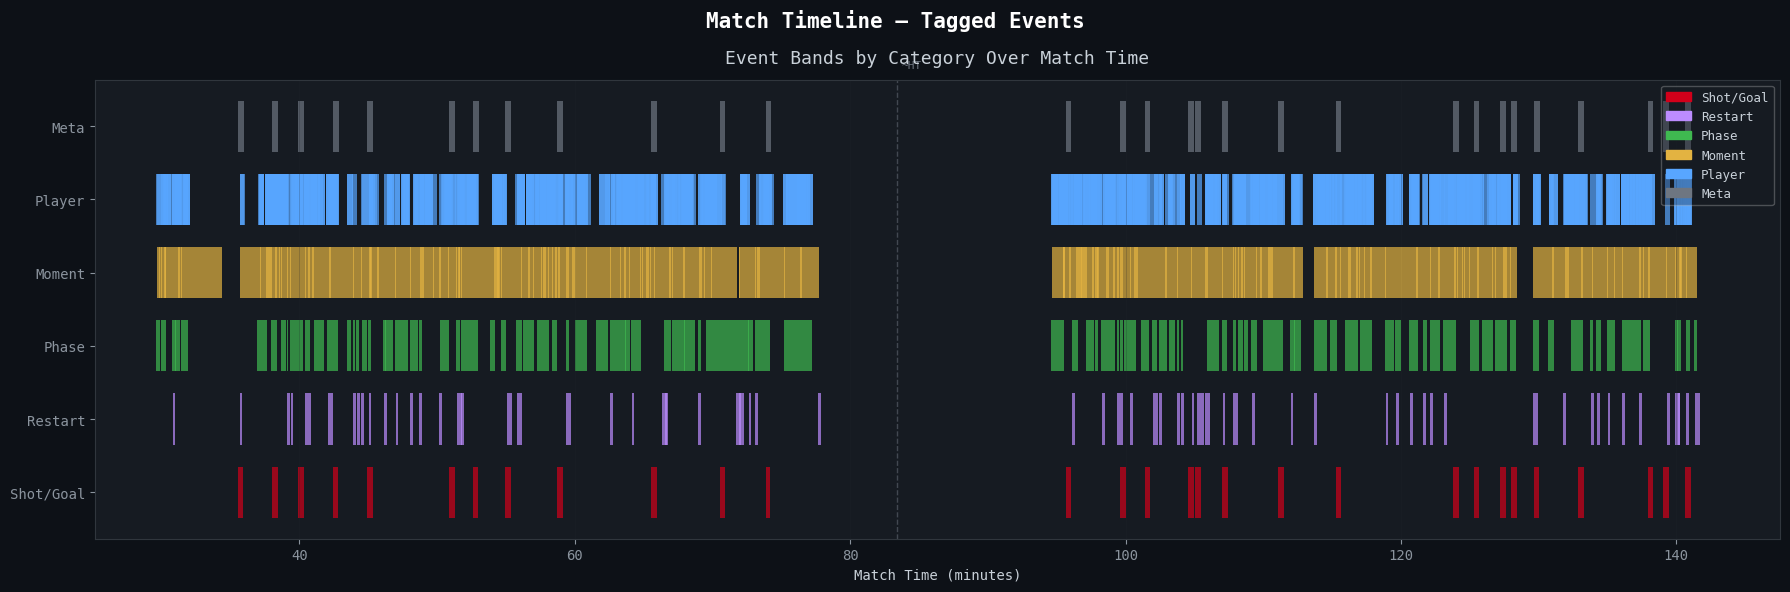

In [6]:
# ─── 2. Match Timeline ─────────────────────────────────────────────────────────
# Show when different code types appear across the match

# Classify codes into categories
def classify_code(code):
    if code.startswith('Player_'):
        return 'Player'
    elif code in ('AANVALLEN', 'VERDEDIGEN', 'V>A', 'A>V', 'BOP'):
        return 'Moment'
    elif code.startswith('DEF') or code.startswith('ATT'):
        return 'Phase'
    elif 'SCHOT' in code or 'DOELPUNT' in code or 'KANS' in code:
        return 'Shot/Goal'
    elif any(x in code for x in ('INGOOI', 'CORNER', 'VRIJE TRAP', 'DOELTRAP')):
        return 'Restart'
    elif code in ('START', 'SUMMARY', 'URBY'):
        return 'Meta'
    else:
        return 'Other'

df['category'] = df['code'].apply(classify_code)

cat_colors = {
    'Player':    ACCENT,
    'Moment':    GOLD,
    'Phase':     GREEN,
    'Shot/Goal': AJAX_RED,
    'Restart':   PURPLE,
    'Meta':      '#6e7681',
    'Other':     ORANGE,
}

cats = ['Shot/Goal', 'Restart', 'Phase', 'Moment', 'Player', 'Meta']

fig, ax = plt.subplots(figsize=(18, 6))
fig.suptitle('Match Timeline — Tagged Events', color=AJAX_WHITE, fontsize=15, fontweight='bold')

for i, cat in enumerate(cats):
    rows = df[df['category'] == cat]
    for _, row in rows.iterrows():
        ax.barh(i, row['duration'] / 60, left=row['start_min'],
                color=cat_colors[cat], alpha=0.7, height=0.7, edgecolor='none')

ax.set_yticks(range(len(cats)))
ax.set_yticklabels(cats)
ax.set_xlabel('Match Time (minutes)')
ax.set_title('Event Bands by Category Over Match Time')
ax.grid(axis='x', alpha=0.3)

legend_patches = [mpatches.Patch(color=cat_colors[c], label=c) for c in cats]
ax.legend(handles=legend_patches, loc='upper right', framealpha=0.3, fontsize=9)

# Mark half-time roughly (if visible)
midpoint = (df['end_min'].max() + df['start_min'].min()) / 2
ax.axvline(midpoint, color='#6e7681', linestyle='--', alpha=0.5, linewidth=1)
ax.text(midpoint + 0.3, len(cats) - 0.2, '~HT', color='#6e7681', fontsize=8)

plt.tight_layout()
plt.show()

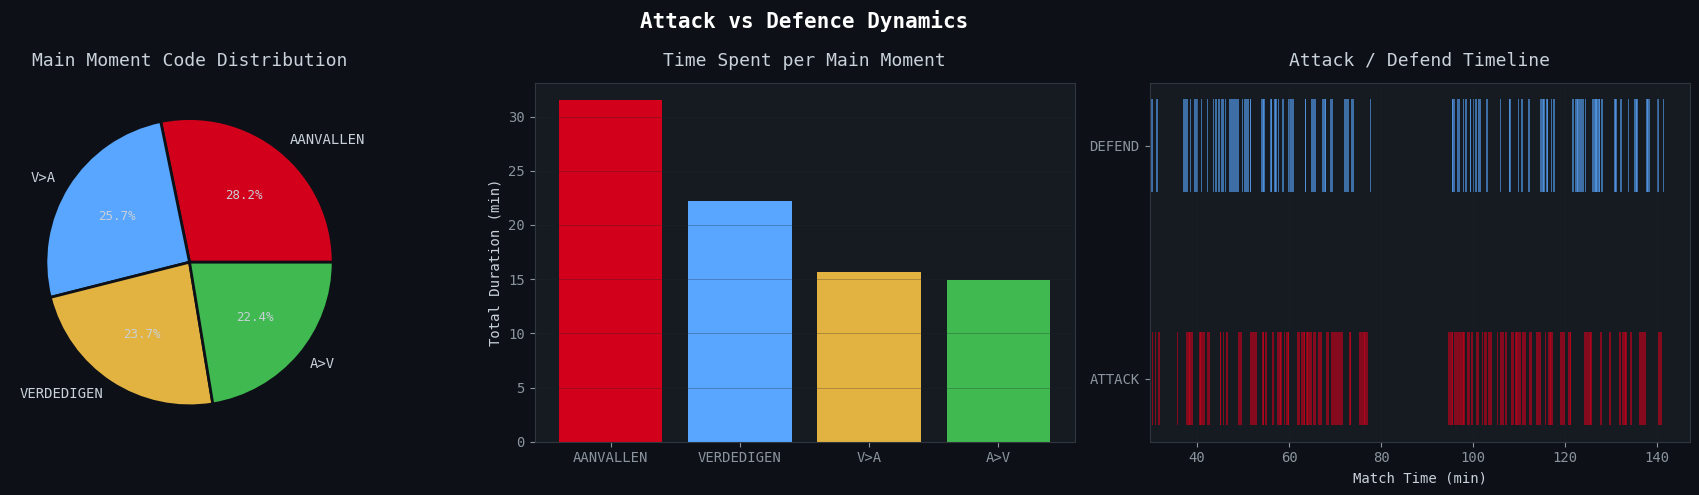


Summary:
  A>V           count= 54  total=15.0 min  avg=16.6s
  AANVALLEN     count= 68  total=31.6 min  avg=27.8s
  V>A           count= 62  total=15.7 min  avg=15.2s
  VERDEDIGEN    count= 57  total=22.2 min  avg=23.4s


In [7]:
# ─── 3. Attacking vs Defending Balance ─────────────────────────────────────────

# Code-level AANVALLEN / VERDEDIGEN / transition instances
main_code_df = df[df['code'].isin(['AANVALLEN', 'VERDEDIGEN', 'V>A', 'A>V'])].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Attack vs Defence Dynamics', color=AJAX_WHITE, fontsize=15, fontweight='bold')

# Pie: count of main moment codes
ax = axes[0]
mc = main_code_df['code'].value_counts()
wedges, texts, autotexts = ax.pie(
    mc.values, labels=mc.index, autopct='%1.1f%%',
    colors=[AJAX_RED, ACCENT, GOLD, GREEN][:len(mc)],
    textprops={'color': '#c9d1d9', 'fontsize': 10},
    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2},
)
for at in autotexts: at.set_fontsize(9)
ax.set_title('Main Moment Code Distribution')

# Duration per moment code
ax = axes[1]
dur_by_code = main_code_df.groupby('code')['duration'].sum().sort_values(ascending=False) / 60
palette = [AJAX_RED, ACCENT, GOLD, GREEN][:len(dur_by_code)]
ax.bar(dur_by_code.index, dur_by_code.values, color=palette, edgecolor='none')
ax.set_ylabel('Total Duration (min)')
ax.set_title('Time Spent per Main Moment')
ax.grid(axis='y', alpha=0.4)

# Timeline: attacking vs defending phases over match
ax = axes[2]
attack_rows = main_code_df[main_code_df['code'].isin(['AANVALLEN', 'A>V'])]
defend_rows = main_code_df[main_code_df['code'].isin(['VERDEDIGEN', 'V>A'])]

for _, r in attack_rows.iterrows():
    ax.barh(0, r['duration']/60, left=r['start_min'], color=AJAX_RED, alpha=0.6, height=0.4)
for _, r in defend_rows.iterrows():
    ax.barh(1, r['duration']/60, left=r['start_min'], color=ACCENT, alpha=0.6, height=0.4)

ax.set_yticks([0, 1])
ax.set_yticklabels(['ATTACK', 'DEFEND'])
ax.set_xlabel('Match Time (min)')
ax.set_title('Attack / Defend Timeline')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Summary numbers
print('\nSummary:')
for code, grp in main_code_df.groupby('code'):
    print(f"  {code:12s}  count={len(grp):3d}  total={grp['duration'].sum()/60:.1f} min  avg={grp['duration'].mean():.1f}s")

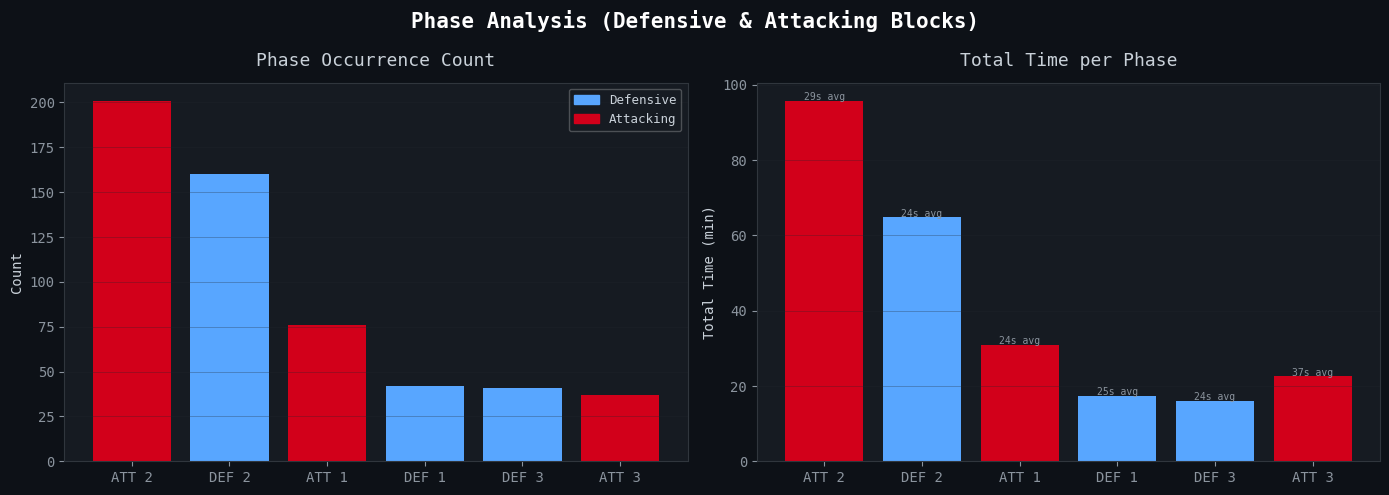


Phase Summary:
phase  count  total_min  avg_s
ATT 2    201      95.82  28.60
DEF 2    160      64.83  24.31
ATT 1     76      31.02  24.49
DEF 1     42      17.44  24.92
DEF 3     41      16.12  23.59
ATT 3     37      22.66  36.75


In [8]:
# ─── 4. Phase Analysis (DEF 1/2/3, ATT 1/2/3) ─────────────────────────────────

phase_rows = []
for _, row in df.iterrows():
    for f in row['fase']:
        phase_rows.append({'phase': f, 'duration': row['duration'], 'start_min': row['start_min']})
    # also grab from code directly if it's a phase
    if row['code'] in ('DEF 1','DEF 2','DEF 3','ATT 1','ATT 2','ATT 3'):
        phase_rows.append({'phase': row['code'], 'duration': row['duration'], 'start_min': row['start_min']})

pdf = pd.DataFrame(phase_rows) if phase_rows else pd.DataFrame()

if not pdf.empty:
    pdf_agg = pdf.groupby('phase').agg(
        count=('duration','count'),
        total_min=('duration', lambda x: x.sum()/60),
        avg_s=('duration','mean')
    ).reset_index().sort_values('count', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Phase Analysis (Defensive & Attacking Blocks)', color=AJAX_WHITE, fontsize=15, fontweight='bold')

    def phase_color(p):
        if p.startswith('DEF'): return ACCENT
        if p.startswith('ATT'): return AJAX_RED
        return GOLD

    colors = [phase_color(p) for p in pdf_agg['phase']]

    ax = axes[0]
    ax.bar(pdf_agg['phase'], pdf_agg['count'], color=colors, edgecolor='none')
    ax.set_ylabel('Count')
    ax.set_title('Phase Occurrence Count')
    ax.grid(axis='y', alpha=0.4)

    ax = axes[1]
    ax.bar(pdf_agg['phase'], pdf_agg['total_min'], color=colors, edgecolor='none')
    ax.set_ylabel('Total Time (min)')
    ax.set_title('Total Time per Phase')
    ax.grid(axis='y', alpha=0.4)
    for i, row in pdf_agg.iterrows():
        ax.text(list(pdf_agg['phase']).index(row['phase']), row['total_min'] + 0.1,
                f"{row['avg_s']:.0f}s avg", ha='center', fontsize=7, color='#8b949e')

    def_patch = mpatches.Patch(color=ACCENT, label='Defensive')
    att_patch = mpatches.Patch(color=AJAX_RED, label='Attacking')
    axes[0].legend(handles=[def_patch, att_patch], fontsize=9, framealpha=0.3)

    plt.tight_layout()
    plt.show()

    print('\nPhase Summary:')
    print(pdf_agg.round(2).to_string(index=False))

In [ ]:
# ─── 5. Shots, Goals & Chances ─────────────────────────────────────────────────

shot_codes = [c for c in df['code'].unique() if any(
    kw in c for kw in ('SCHOT','DOELPUNT','KANS','CORNER','VRIJE TRAP','INGOOI','DOELTRAP'))]

shot_df = df[df['code'].isin(shot_codes)].copy()
shot_df['team'] = shot_df['code'].apply(lambda c: 'AJAX' if c.startswith('AJAX') else 'FORTUNA')
shot_df['event_type'] = shot_df['code'].apply(lambda c: c.split(' | ')[-1] if ' | ' in c else c)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Match Events — Shots, Goals & Set Pieces', color=AJAX_WHITE, fontsize=15, fontweight='bold')

# By team
ax = axes[0]
team_counts = shot_df.groupby(['team','event_type']).size().unstack(fill_value=0)
team_counts.plot(kind='bar', ax=ax, colormap='RdYlGn', edgecolor='none', rot=0)
ax.set_title('Events by Team')
ax.set_ylabel('Count')
ax.legend(fontsize=8, framealpha=0.3)
ax.grid(axis='y', alpha=0.4)

# Timeline of key events
ax = axes[1]
event_colors = {
    'DOELPUNT': GOLD,
    'SCHOT': AJAX_RED,
    'KANS': ORANGE,
    'CORNER': GREEN,
    'INGOOI': PURPLE,
    'VRIJE TRAP OVERIG': ACCENT,
    'VRIJE TRAP GEVAARLIJK': '#ff7b00',
    'DOELTRAP': '#6e7681',
}
for _, row in shot_df.iterrows():
    color = event_colors.get(row['event_type'], '#ffffff')
    marker = '*' if 'DOELPUNT' in row['code'] else ('s' if 'SCHOT' in row['code'] else 'o')
    size = 200 if 'DOELPUNT' in row['code'] else (80 if 'SCHOT' in row['code'] else 50)
    y = 0 if row['team'] == 'AJAX' else 1
    ax.scatter(row['start_min'], y, c=color, s=size, marker=marker, zorder=5, edgecolors='white', linewidths=0.5)

ax.set_yticks([0, 1])
ax.set_yticklabels(['AJAX', 'FORTUNA'])
ax.set_xlabel('Match Time (min)')
ax.set_title('Event Timeline by Team')
ax.grid(alpha=0.3)

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in list(event_colors.items())[:6]]
ax.legend(handles=legend_patches, fontsize=7, framealpha=0.3, loc='lower right')

# Total counts
ax = axes[2]
event_totals = shot_df['event_type'].value_counts()
bar_colors = [event_colors.get(e, ACCENT) for e in event_totals.index]
ax.barh(event_totals.index, event_totals.values, color=bar_colors, edgecolor='none')
ax.set_xlabel('Count')
ax.set_title('Total Event Counts')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.4)
for i, v in enumerate(event_totals.values):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9, color='#8b949e')

plt.tight_layout()
plt.show()

# Goals summary
goals = shot_df[shot_df['event_type'] == 'DOELPUNT'][['team','start_min','code']]
if not goals.empty:
    print('\nGOALS:')
    for _, g in goals.iterrows():
        print(f"  {g['team']:10s}  {g['start_min']:.1f} min  — {g['code']}")
else:
    print('No goals tagged in this dataset.')

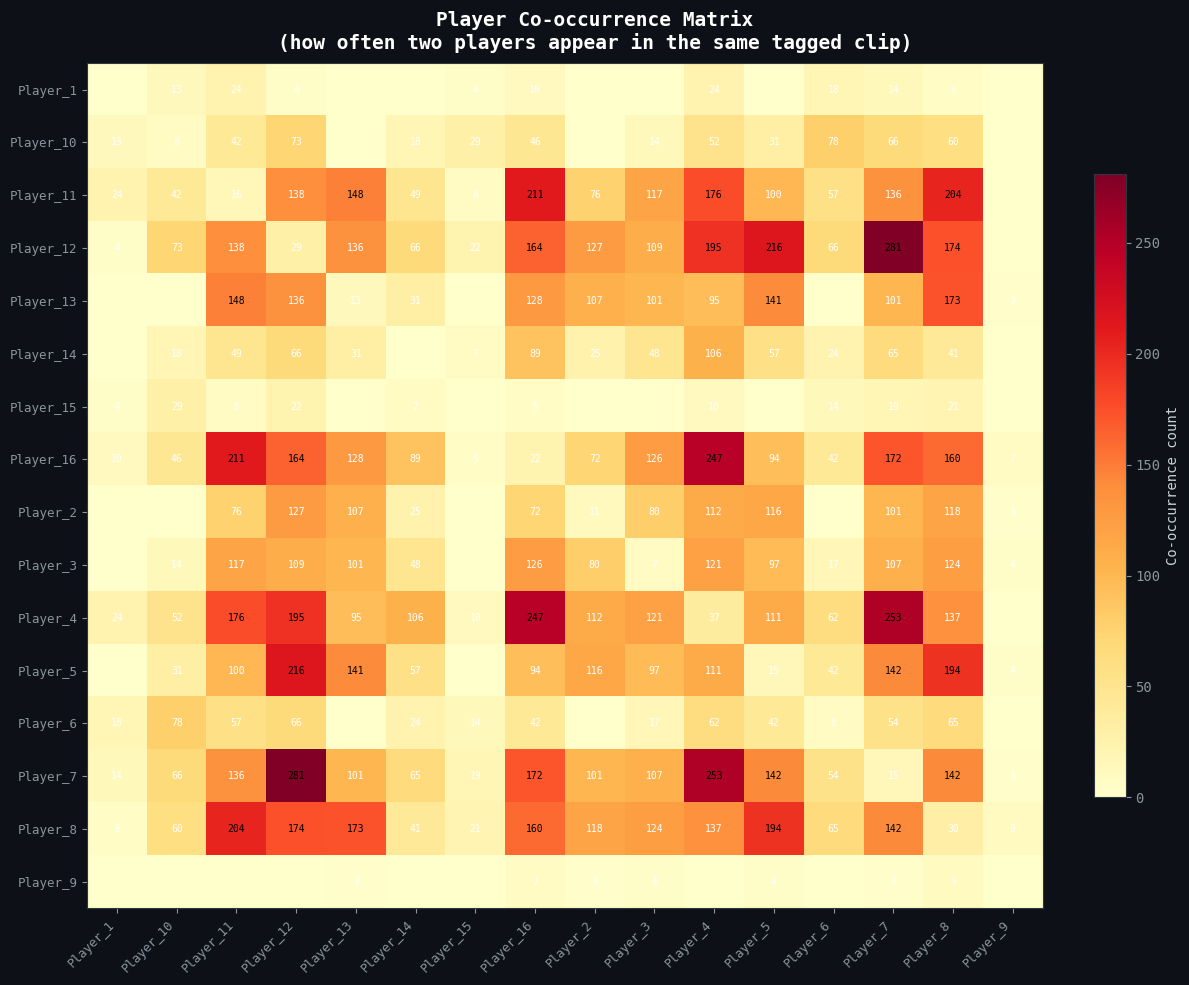


Top 15 Player Pairs:
  Player_12    + Player_7      →  281 clips
  Player_4     + Player_7      →  253 clips
  Player_16    + Player_4      →  247 clips
  Player_12    + Player_5      →  216 clips
  Player_11    + Player_16     →  211 clips
  Player_11    + Player_8      →  204 clips
  Player_12    + Player_4      →  195 clips
  Player_5     + Player_8      →  194 clips
  Player_11    + Player_4      →  176 clips
  Player_12    + Player_8      →  174 clips
  Player_13    + Player_8      →  173 clips
  Player_16    + Player_7      →  172 clips
  Player_12    + Player_16     →  164 clips
  Player_16    + Player_8      →  160 clips
  Player_11    + Player_13     →  148 clips


In [9]:
# ─── 6. Player Co-occurrence ────────────────────────────────────────────────────
# Which players appear together most often?

from itertools import combinations
import numpy as np

cooccurrence = Counter()
for _, row in df.iterrows():
    players = sorted(row['spelers'])
    for pair in combinations(players, 2):
        cooccurrence[pair] += 1

# Build matrix
n = len(all_players)
mat = np.zeros((n, n))
pidx = {p: i for i, p in enumerate(all_players)}
for (p1, p2), cnt in cooccurrence.items():
    if p1 in pidx and p2 in pidx:
        mat[pidx[p1], pidx[p2]] = cnt
        mat[pidx[p2], pidx[p1]] = cnt

fig, ax = plt.subplots(figsize=(12, 10))
fig.suptitle('Player Co-occurrence Matrix\n(how often two players appear in the same tagged clip)',
             color=AJAX_WHITE, fontsize=14, fontweight='bold')

im = ax.imshow(mat, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(all_players, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_players, fontsize=9)

for i in range(n):
    for j in range(n):
        if mat[i, j] > 0:
            ax.text(j, i, int(mat[i, j]), ha='center', va='center',
                    fontsize=7, color='black' if mat[i,j] > mat.max()*0.5 else 'white')

plt.colorbar(im, ax=ax, label='Co-occurrence count', fraction=0.03)
plt.tight_layout()
plt.show()

print('\nTop 15 Player Pairs:')
for (p1, p2), cnt in cooccurrence.most_common(15):
    print(f'  {p1:12s} + {p2:12s}  →  {cnt:3d} clips')

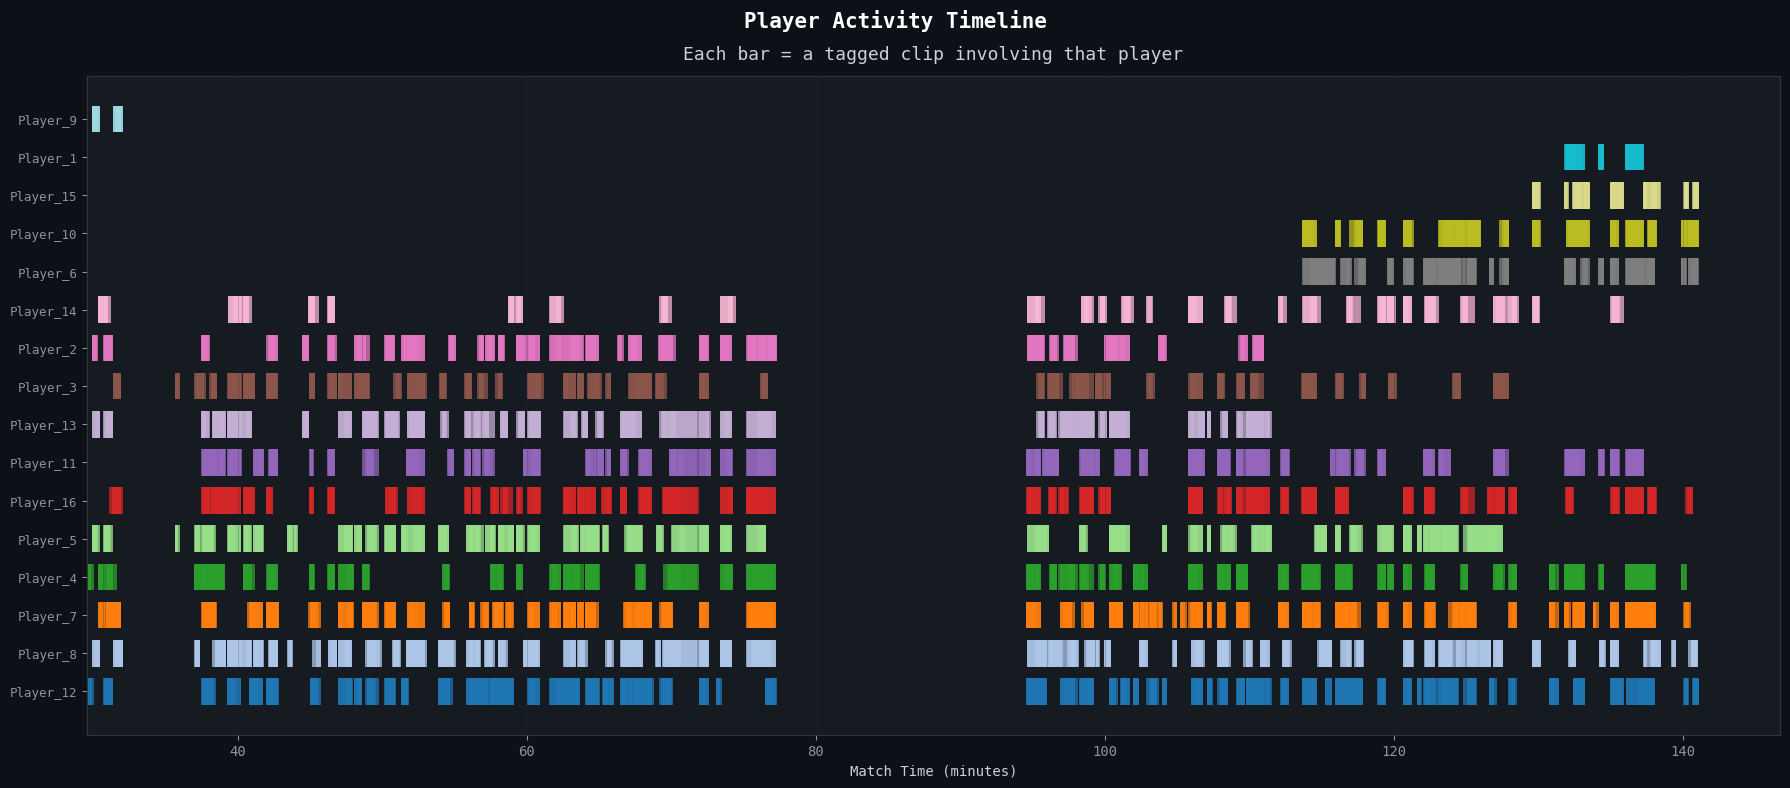

In [10]:
# ─── 7. Player Activity Timeline ───────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(18, 8))
fig.suptitle('Player Activity Timeline', color=AJAX_WHITE, fontsize=15, fontweight='bold')

player_order = pstats['player'].tolist()  # sorted by most active
cmap = plt.colormaps['tab20'].resampled(len(player_order))

for i, player in enumerate(player_order):
    rows = df[df['spelers'].apply(lambda s: player in s)]
    color = cmap(i)
    for _, row in rows.iterrows():
        ax.barh(i, row['duration']/60, left=row['start_min'],
                color=color, alpha=0.75, height=0.7, edgecolor='none')

ax.set_yticks(range(len(player_order)))
ax.set_yticklabels(player_order, fontsize=9)
ax.set_xlabel('Match Time (minutes)')
ax.set_title("Each bar = a tagged clip involving that player")
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

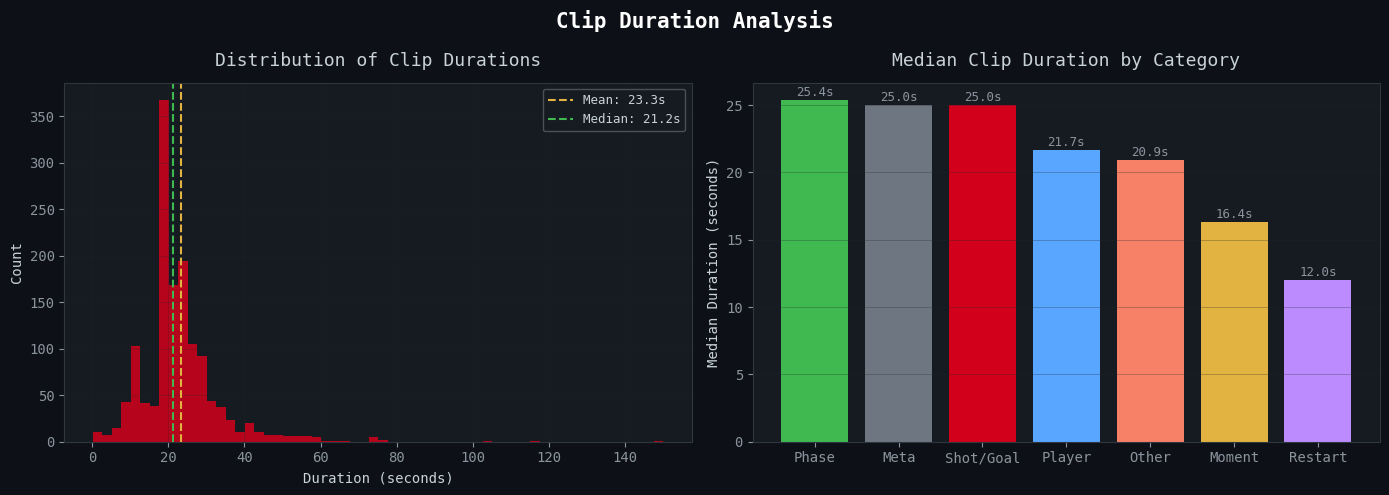

In [11]:
# ─── 8. Clip Duration Distribution ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Clip Duration Analysis', color=AJAX_WHITE, fontsize=15, fontweight='bold')

ax = axes[0]
ax.hist(df['duration'], bins=60, color=AJAX_RED, edgecolor='none', alpha=0.85)
ax.axvline(df['duration'].mean(), color=GOLD, linewidth=1.5, linestyle='--', label=f"Mean: {df['duration'].mean():.1f}s")
ax.axvline(df['duration'].median(), color=GREEN, linewidth=1.5, linestyle='--', label=f"Median: {df['duration'].median():.1f}s")
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Clip Durations')
ax.legend(fontsize=9, framealpha=0.3)
ax.grid(alpha=0.3)

# Duration by category
ax = axes[1]
cat_durations = df.groupby('category')['duration'].median().sort_values(ascending=False)
colors = [cat_colors.get(c, ACCENT) for c in cat_durations.index]
ax.bar(cat_durations.index, cat_durations.values, color=colors, edgecolor='none')
ax.set_ylabel('Median Duration (seconds)')
ax.set_title('Median Clip Duration by Category')
ax.grid(axis='y', alpha=0.4)
for i, (cat, val) in enumerate(cat_durations.items()):
    ax.text(i, val + 0.3, f'{val:.1f}s', ha='center', fontsize=9, color='#8b949e')

plt.tight_layout()
plt.show()

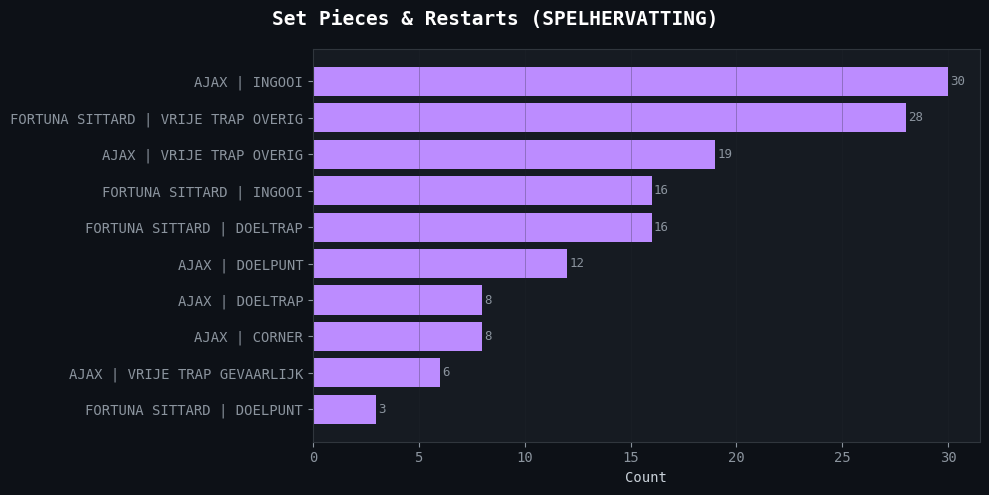

In [12]:
# ─── 9. Set Pieces & Restarts ──────────────────────────────────────────────────

restart_rows = []
for _, row in df.iterrows():
    for r in row['spelhervatting']:
        restart_rows.append({'restart': r, 'duration': row['duration'], 'start_min': row['start_min']})

if restart_rows:
    rdf = pd.DataFrame(restart_rows)
    restart_counts = rdf['restart'].value_counts()

    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle('Set Pieces & Restarts (SPELHERVATTING)', color=AJAX_WHITE, fontsize=14, fontweight='bold')
    bars = ax.barh(restart_counts.index, restart_counts.values, color=PURPLE, edgecolor='none')
    ax.set_xlabel('Count')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.4)
    for bar, val in zip(bars, restart_counts.values):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, str(val),
                va='center', fontsize=9, color='#8b949e')
    plt.tight_layout()
    plt.show()
else:
    print('No SPELHERVATTING labels found in data.')

In [13]:
# ─── 10. Raw Data Explorer ─────────────────────────────────────────────────────
# Filter and search instances interactively

def search_instances(code_contains=None, player=None, phase=None, moment=None,
                     min_duration=None, max_duration=None, n=20):
    """
    Search and filter instances.
    
    Examples:
        search_instances(player='Player_7')               # All clips with Player_7
        search_instances(code_contains='SCHOT')            # All shot clips
        search_instances(phase='DEF 2', player='Player_4') # DEF 2 phase with Player_4
        search_instances(moment='V>A', min_duration=10)    # V>A transitions > 10s
    """
    mask = pd.Series([True] * len(df), index=df.index)

    if code_contains:
        mask &= df['code'].str.contains(code_contains, case=False, na=False)
    if player:
        mask &= df['spelers'].apply(lambda s: player in s)
    if phase:
        mask &= df['fase'].apply(lambda fs: phase in fs)
    if moment:
        mask &= df['hoofdmomenten'].apply(lambda ms: moment in ms)
    if min_duration is not None:
        mask &= df['duration'] >= min_duration
    if max_duration is not None:
        mask &= df['duration'] <= max_duration

    result = df[mask][['id','start_min','end_min','duration','code','spelers','hoofdmomenten','fase']].copy()
    result.columns = ['ID','Start(min)','End(min)','Dur(s)','Code','Players','Moment','Phase']
    result['Start(min)'] = result['Start(min)'].round(2)
    result['End(min)']   = result['End(min)'].round(2)
    result['Dur(s)']     = result['Dur(s)'].round(1)

    print(f'Found {len(result)} instances matching your query.')
    return result.head(n)

# ── Example queries — uncomment and run what you need ──

# All clips involving Player_7
display(search_instances(player='Player_7', n=10))

# All AJAX shot clips
# display(search_instances(code_contains='AJAX | SCHOT'))

# Transitions (V>A) longer than 15 seconds
# display(search_instances(moment='V>A', min_duration=15))

# DEF 2 phase clips
# display(search_instances(phase='DEF 2', n=15))

Found 408 instances matching your query.


,ID,Start(min),End(min),Dur(s),Code,Players,Moment,Phase
17,18,30.35,30.69,20.0,Player_7,"[Player_7, Player_4, Player_14]",[],[]
19,20,30.38,30.53,9.0,FORTUNA SITTARD | BUITENSPEL,"[Player_7, Player_4, Player_14]",[],[]
20,21,30.49,30.82,19.5,BOP,"[Player_7, Player_4, Player_14]",[],[]
22,23,30.75,31.40,38.9,Player_5,"[Player_5, Player_2, Player_12, Player_13, Pla...","[VERDEDIGEN, V>A]",[DEF 3]
27,28,30.91,31.38,28.1,Player_2,"[Player_2, Player_12, Player_13, Player_4, Pla...",[V>A],[]
28,29,30.93,31.40,28.1,Player_12,"[Player_12, Player_13, Player_4, Player_7]",[V>A],[]
30,31,30.99,31.38,23.3,Player_13,"[Player_13, Player_4, Player_7]",[V>A],[]
32,33,31.09,31.66,34.4,Player_4,"[Player_4, Player_7, Player_16]","[V>A, AANVALLEN]",[ATT 2]
33,34,31.16,31.49,20.0,Player_7,[Player_7],[AANVALLEN],[ATT 2]
34,35,31.20,31.45,15.0,V>A,[Player_7],[V>A],[]


In [14]:
# ─── 11. Export to CSV ─────────────────────────────────────────────────────────

export_df = df[['id','start','end','start_min','end_min','duration','code','category',
                'n_players','free_text']].copy()

# Flatten list columns
export_df['spelers']        = df['spelers'].apply(lambda x: ', '.join(x))
export_df['hoofdmomenten']  = df['hoofdmomenten'].apply(lambda x: ', '.join(x))
export_df['fase']           = df['fase'].apply(lambda x: ', '.join(x))
export_df['spelhervatting'] = df['spelhervatting'].apply(lambda x: ', '.join(x))

out_path = 'data/instances_parsed.csv'
export_df.to_csv(out_path, index=False)
print(f'Exported {len(export_df)} rows to {out_path}')
display(export_df.head(5))

Exported 1381 rows to data/instances_parsed.csv


,id,start,end,start_min,end_min,duration,code,category,n_players,free_text,spelers,hoofdmomenten,fase,spelhervatting
0,1,1509.600000,1509.928989,25.160000,25.165483,0.328989,URBY,Meta,0,test,,,,
1,2,1775.996894,1804.997098,29.599948,30.083285,29.000203,Player_4,Player,2,,"Player_4, Player_12","V>A, VERDEDIGEN",DEF 2,
2,3,1776.296562,1792.896639,29.604943,29.881611,16.600077,DEF 2,Phase,2,,"Player_4, Player_12",,DEF 2,
3,4,1777.697104,1797.697104,29.628285,29.961618,20.000000,Player_12,Player,1,,Player_12,V>A,,
4,5,1778.395187,1792.896639,29.639920,29.881611,14.501451,VERDEDIGEN,Moment,2,,"Player_4, Player_12",VERDEDIGEN,DEF 2,
